In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
table_path = Path.cwd()
table_name = table_path / "questionnaire_results.xlsx"

table_name

WindowsPath('D:/thesis-matlab-pipeline/analysis/questionnaire_results.xlsx')

In [3]:
df = pd.read_excel(table_name)

df

,idx,id,poc_cue,poc_face,hp_cue,hp_face,im_cue,im_face,am_cue,am_face
0,vp01,JW,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0
1,vp02,SG,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,vp03,AS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,vp04,NH,3.0,5.0,5.0,5.0,0.0,5.0,5.0,5.0
4,vp05,ET,4.0,5.0,5.0,4.0,4.0,4.0,5.0,5.0
5,vp06,LK,3.0,5.0,5.0,5.0,4.0,3.0,5.0,5.0
6,vp07,JF,0.0,5.0,2.0,2.0,2.0,5.0,5.0,5.0
7,vp08,RR,4.0,4.0,5.0,5.0,4.0,4.0,5.0,5.0
8,vp09,MH,3.0,4.0,5.0,2.0,3.0,0.0,4.0,5.0
9,vp10,YM,5.0,5.0,5.0,5.0,0.0,3.0,5.0,5.0


In [4]:
# Fill NaN with Means
for col in df:
    try:
        df[col] = df[col].fillna(df[col].mean())
    except TypeError:
        continue

df

,idx,id,poc_cue,poc_face,hp_cue,hp_face,im_cue,im_face,am_cue,am_face
0,vp01,JW,5.000000,5.000000,5.0,5.000000,5.0,5.000000,5.000000,5.000000
1,vp02,SG,3.333333,4.266667,4.6,3.933333,2.2,3.066667,4.533333,4.733333
2,vp03,AS,3.333333,4.266667,4.6,3.933333,2.2,3.066667,4.533333,4.733333
3,vp04,NH,3.000000,5.000000,5.0,5.000000,0.0,5.000000,5.000000,5.000000
4,vp05,ET,4.000000,5.000000,5.0,4.000000,4.0,4.000000,5.000000,5.000000
5,vp06,LK,3.000000,5.000000,5.0,5.000000,4.0,3.000000,5.000000,5.000000
6,vp07,JF,0.000000,5.000000,2.0,2.000000,2.0,5.000000,5.000000,5.000000
7,vp08,RR,4.000000,4.000000,5.0,5.000000,4.0,4.000000,5.000000,5.000000
8,vp09,MH,3.000000,4.000000,5.0,2.000000,3.0,0.000000,4.000000,5.000000
9,vp10,YM,5.000000,5.000000,5.0,5.000000,0.0,3.000000,5.000000,5.000000


In [5]:
# Compute cue_avg, face_avg and total_avg per participant
cue_cols = [col for col in df if "_cue" in col]
face_cols = [col for col in df if "_face" in col]

df["cue_avg"] = df[cue_cols].mean(axis=1)
df["face_avg"] = df[face_cols].mean(axis=1)

df["total_avg"] = df[["cue_avg", "face_avg"]].mean(axis=1)

df = df.sort_values(by="total_avg", ascending= False)

df

,idx,id,poc_cue,poc_face,hp_cue,hp_face,im_cue,im_face,am_cue,am_face,cue_avg,face_avg,total_avg
0,vp01,JW,5.000000,5.000000,5.0,5.000000,5.0,5.000000,5.000000,5.000000,5.000000,5.00,5.000000
4,vp05,ET,4.000000,5.000000,5.0,4.000000,4.0,4.000000,5.000000,5.000000,4.500000,4.50,4.500000
17,vp18,LS,4.000000,5.000000,5.0,5.000000,3.0,4.000000,5.000000,5.000000,4.250000,4.75,4.500000
7,vp08,RR,4.000000,4.000000,5.0,5.000000,4.0,4.000000,5.000000,5.000000,4.500000,4.50,4.500000
10,vp11,KL,4.000000,5.000000,5.0,4.000000,3.0,4.000000,5.000000,5.000000,4.250000,4.50,4.375000
5,vp06,LK,3.000000,5.000000,5.0,5.000000,4.0,3.000000,5.000000,5.000000,4.250000,4.50,4.375000
9,vp10,YM,5.000000,5.000000,5.0,5.000000,0.0,3.000000,5.000000,5.000000,3.750000,4.50,4.125000
3,vp04,NH,3.000000,5.000000,5.0,5.000000,0.0,5.000000,5.000000,5.000000,3.250000,5.00,4.125000
14,vp15,LJ,4.000000,4.000000,4.0,4.000000,3.0,4.000000,4.000000,4.000000,3.750000,4.00,3.875000
1,vp02,SG,3.333333,4.266667,4.6,3.933333,2.2,3.066667,4.533333,4.733333,3.666667,4.00,3.833333


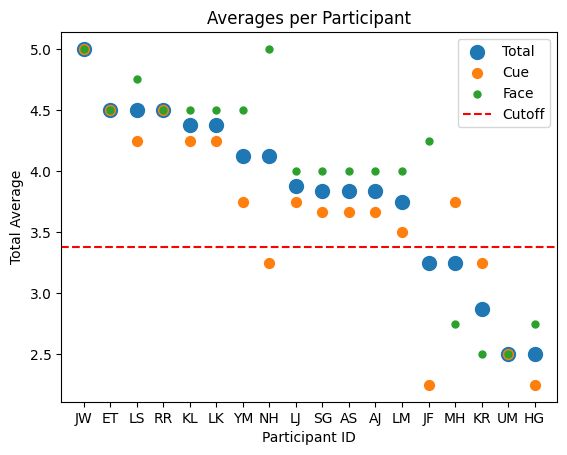

In [6]:
# Plot average recognition (cue, face, total) per participant
cutoff = df["total_avg"].quantile(0.25)

plt.scatter(df["id"], df["total_avg"], label= "Total", s= 100)
plt.scatter(df["id"], df["cue_avg"], label= "Cue", s= 50)
plt.scatter(df["id"], df["face_avg"], label= "Face", s= 25)
plt.axhline(cutoff, linestyle= "--", label= "Cutoff", color = "red")
plt.title("Averages per Participant")
plt.xlabel("Participant ID")
plt.ylabel("Total Average")
plt.legend()

plt.show()

In [7]:
df["cutoff"] = df["total_avg"] >= cutoff

df

,idx,id,poc_cue,poc_face,hp_cue,hp_face,im_cue,im_face,am_cue,am_face,cue_avg,face_avg,total_avg,cutoff
0,vp01,JW,5.000000,5.000000,5.0,5.000000,5.0,5.000000,5.000000,5.000000,5.000000,5.00,5.000000,True
4,vp05,ET,4.000000,5.000000,5.0,4.000000,4.0,4.000000,5.000000,5.000000,4.500000,4.50,4.500000,True
17,vp18,LS,4.000000,5.000000,5.0,5.000000,3.0,4.000000,5.000000,5.000000,4.250000,4.75,4.500000,True
7,vp08,RR,4.000000,4.000000,5.0,5.000000,4.0,4.000000,5.000000,5.000000,4.500000,4.50,4.500000,True
10,vp11,KL,4.000000,5.000000,5.0,4.000000,3.0,4.000000,5.000000,5.000000,4.250000,4.50,4.375000,True
5,vp06,LK,3.000000,5.000000,5.0,5.000000,4.0,3.000000,5.000000,5.000000,4.250000,4.50,4.375000,True
9,vp10,YM,5.000000,5.000000,5.0,5.000000,0.0,3.000000,5.000000,5.000000,3.750000,4.50,4.125000,True
3,vp04,NH,3.000000,5.000000,5.0,5.000000,0.0,5.000000,5.000000,5.000000,3.250000,5.00,4.125000,True
14,vp15,LJ,4.000000,4.000000,4.0,4.000000,3.0,4.000000,4.000000,4.000000,3.750000,4.00,3.875000,True
1,vp02,SG,3.333333,4.266667,4.6,3.933333,2.2,3.066667,4.533333,4.733333,3.666667,4.00,3.833333,True


In [8]:
# Safe clean file to Excel

clean_name = table_path / "clean_questionnaire_results.xlsx"

df.to_excel(clean_name, index= False)

print(f"Cleaned and processed df saved to {clean_name}.")

Cleaned and processed df saved to D:\thesis-matlab-pipeline\analysis\clean_questionnaire_results.xlsx.
